In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import folium
from scipy import stats

In [2]:

df = pd.read_csv("C:/Users/kyoan/Documents/Python_Sorbonne/Python_webscrapping/logements_étudiants.xls")
df = df.loc[df['Loyer'].notna(), ['code', 'ville', 'Adresse', 'Loyer', 'Superficie', 'Type', 'Description', 'Équipements']]

# Extraction de la superficie en metres carrés des logements.

# Extraire les nombres (avec points décimaux)
df['Superficie_m2'] = df['Superficie'].str.extract(r'(\d+[.,]?\d*)')

# Convertir en float (remplacer virgule par point)
df['Superficie_m2'] = df['Superficie_m2'].str.replace(',', '.', regex=False)

# Convertir en float
df['Superficie_m2'] = pd.to_numeric(df['Superficie_m2'], errors='coerce')

df.drop(['Superficie',], axis=1, inplace = True)

# Arrangement de la colonne 'Loyer' (Extraction du prix sans comentaires)

# Convertir d'abord à string et extraire les chiffres.
df['Loyer'] = df['Loyer'].astype(str).str.extract(r'(\d+[.,]?\d*)')

# Rremplacer virgule par point
df['Loyer'] = df['Loyer'].str.replace(',', '.', regex=False)

# Convertir en float
df['Loyer'] = pd.to_numeric(df['Loyer'], errors='coerce')

# Enlever les traits te les espaces à droite.
df['Adresse'] = df['Adresse'].str.split('-').str[0]

# Garder uniquement les lignes qui contiennent au moins une lettre
df = df[df['ville'].astype(str).str.contains(r'[a-zA-Z]', na=False)]
df

,code,ville,Adresse,Loyer,Type,Description,Équipements,Superficie_m2
5,19000,TULLE,35 rue d'Arsonval,403.59,cohabitation Individuel,"Studio équipé pour une personne lit 90x200, ta...","WC, Douche, Evier + plaque, Frigo",26.0
13,-,CANNES,13 boulevard d Oxford,444.19,résidence conventionnée,"Equipement kitchenette, évier, réfrigérateur, ...","WC, Douche, Evier + plaque, Frigo, Micro-onde",18.0
18,38000,GRENOBLE,2 avenue Général Champon,313.50,cohabitation Individuel,Résidence Le Home des étudiants - Crous Grenob...,"Pièce à vivre, WC, Douche, Evier + plaque, Frigo",9.0
24,06560,VALBONNE,2255 route des Dolines,409.55,résidence conventionnée,Type de logement 190 T1 de 21 m2 - 1 pers Équi...,"WC, Douche, Evier + plaque, Frigo, Balcon",21.0
35,06560,VALBONNE,2255 route des Dolines,490.46,résidence conventionnée,Type de logement 32 T1 BIS de 31 m2 - 1 ou 2 p...,"WC, Douche, Evier + plaque, Frigo, Balcon",32.0
...,...,...,...,...,...,...,...,...
2694,34090,Montpellier,119 Rue du Faubourg Boutonnet,396.81,cohabitation Individuel,"Les 68 studios de 19 m², entièrement équipés e...","WC, Douche, Evier + plaque, Frigo",19.0
2740,38000,Grenoble,3 bis rue Moyrand,362.00,cohabitation Individuel,Logements individuels d'une superficie de 19 à...,"WC, Douche, Evier + plaque, Frigo",19.5
2762,87100,LIMOGES,18 boulevard de la Borie,438.00,cohabitation Individuel,Appartement pour une personne séjour-chambre é...,"WC, Douche, Evier + plaque, Frigo, Balcon",32.0
2773,23500,FELLETIN,41 bis Route d'Aubusson,246.14,cohabitation Individuel,"Chambre équipée pour une personne lit, chevet,...","Evier + plaque, Frigo",9.0


In [3]:
# Créer un dataframe temporaire
mask_cedex = df['ville'].astype(str).str.contains('CEDEX', case=False, na=False)

# Échanger en une seule opération
df.loc[mask_cedex, ['ville', 'code']] = df.loc[mask_cedex, ['code', 'ville']].values

# Pareil avec Cédex
mask_cedex = df['ville'].astype(str).str.contains('cédex', case=False, na=False)

# Échanger en une seule opération
df.loc[mask_cedex, ['ville', 'code']] = df.loc[mask_cedex, ['code', 'ville']].values

In [4]:
# Trouver des codes postals manquantes

df_hexa = pd.read_csv('019HexaSmal-full.csv')
df_hexa = df_hexa[['Nom_de_la_commune', 'Code_postal']]
df_hexa = df_hexa.rename(columns={'Nom_de_la_commune': 'ville'})
df_hexa['Code_postal'] = df_hexa['Code_postal'].astype(str)
df_hexa = df_hexa.drop_duplicates(subset='ville', keep='first')

df_ville = df['ville'].str.upper()

l_joint = pd.merge(df_ville, df_hexa, on='ville', how='left')
l_joint['Code_postal'] = l_joint['Code_postal'].fillna('').apply(
    lambda x: str(int(x)).zfill(5) if pd.notnull(x) and str(x).isdigit() else str(x) )

df['code'] = l_joint['Code_postal'].values
df = df[df['code'] != '']
df = df.reset_index(drop=True)
df

FileNotFoundError: [Errno 2] No such file or directory: '019HexaSmal-full.csv'

In [5]:
# Création du DataFrame des codes par regions
data = {
    'code_region': ['84', '32', '93', '44', '76', '75', '11', '28', '27', '53', '24', '52', '94'],
    'nom_region': [
        'Auvergne-Rhône-Alpes',
        'Hauts-de-France',
        'Provence-Alpes-Côte d\'Azur',
        'Grand Est',
        'Occitanie',
        'Nouvelle-Aquitaine',
        'Île-de-France',
        'Normandie',
        'Bourgogne-Franche-Comté',
        'Bretagne',
        'Centre-Val de Loire',
        'Pays de la Loire',
        'Corse'
    ],
    'departements': [
        ['01', '03', '07', '15', '26', '38', '42', '43', '63', '69', '73', '74'],
        ['02', '59', '60', '62', '80'],
        ['04', '05', '06', '13', '83', '84'],
        ['08', '10', '51', '52', '54', '55', '57', '67', '68', '88'],
        ['09', '11', '12', '30', '31', '32', '34', '46', '48', '65', '66', '81', '82'],
        ['16', '17', '19', '23', '24', '33', '40', '47', '64', '79', '86', '87'],
        ['75', '77', '78', '91', '92', '93', '94', '95'],
        ['14', '27', '50', '61', '76'],
        ['21', '25', '39', '58', '70', '71', '89', '90'],
        ['22', '29', '35', '56'],
        ['18', '28', '36', '37', '41', '45'],
        ['44', '49', '53', '72', '85'],
        ['2A', '2B']
    ]
}

df_regions = pd.DataFrame(data)
df_regions

,code_region,nom_region,departements
0,84,Auvergne-Rhône-Alpes,"[01, 03, 07, 15, 26, 38, 42, 43, 63, 69, 73, 74]"
1,32,Hauts-de-France,"[02, 59, 60, 62, 80]"
2,93,Provence-Alpes-Côte d'Azur,"[04, 05, 06, 13, 83, 84]"
3,44,Grand Est,"[08, 10, 51, 52, 54, 55, 57, 67, 68, 88]"
4,76,Occitanie,"[09, 11, 12, 30, 31, 32, 34, 46, 48, 65, 66, 8..."
5,75,Nouvelle-Aquitaine,"[16, 17, 19, 23, 24, 33, 40, 47, 64, 79, 86, 87]"
6,11,Île-de-France,"[75, 77, 78, 91, 92, 93, 94, 95]"
7,28,Normandie,"[14, 27, 50, 61, 76]"
8,27,Bourgogne-Franche-Comté,"[21, 25, 39, 58, 70, 71, 89, 90]"
9,53,Bretagne,"[22, 29, 35, 56]"


In [6]:
import re
# Prix par m2 par département
df['Prix_m2'] = (df['Loyer'] / df['Superficie_m2']).round(2)


df['code'] = df['code'].apply(lambda x: str(x) if re.match(r'(\d+[.,]?\d*)', str(x)) else None)

# Créer la catégorie 'departement' pour analyser le prix par departement.
df['departements'] = df['code'].str[:2]
df['departements'] = df['departements'].astype('category')

regions = df_regions.explode('departements')

df = pd.merge(
    df, 
    regions[['departements','code_region', 'nom''_region']],
    on = 'departements',
    how = 'left'
)

df

,code,ville,Adresse,Loyer,Type,Description,Équipements,Superficie_m2,Prix_m2,departements,code_region,nom_region
0,19000,TULLE,35 rue d'Arsonval,403.59,cohabitation Individuel,"Studio équipé pour une personne lit 90x200, ta...","WC, Douche, Evier + plaque, Frigo",26.0,15.52,19,75,Nouvelle-Aquitaine
1,None,CANNES,13 boulevard d Oxford,444.19,résidence conventionnée,"Equipement kitchenette, évier, réfrigérateur, ...","WC, Douche, Evier + plaque, Frigo, Micro-onde",18.0,24.68,NaN,NaN,NaN
2,38000,GRENOBLE,2 avenue Général Champon,313.50,cohabitation Individuel,Résidence Le Home des étudiants - Crous Grenob...,"Pièce à vivre, WC, Douche, Evier + plaque, Frigo",9.0,34.83,38,84,Auvergne-Rhône-Alpes
3,06560,VALBONNE,2255 route des Dolines,409.55,résidence conventionnée,Type de logement 190 T1 de 21 m2 - 1 pers Équi...,"WC, Douche, Evier + plaque, Frigo, Balcon",21.0,19.50,06,93,Provence-Alpes-Côte d'Azur
4,06560,VALBONNE,2255 route des Dolines,490.46,résidence conventionnée,Type de logement 32 T1 BIS de 31 m2 - 1 ou 2 p...,"WC, Douche, Evier + plaque, Frigo, Balcon",32.0,15.33,06,93,Provence-Alpes-Côte d'Azur
...,...,...,...,...,...,...,...,...,...,...,...,...
291,34090,Montpellier,119 Rue du Faubourg Boutonnet,396.81,cohabitation Individuel,"Les 68 studios de 19 m², entièrement équipés e...","WC, Douche, Evier + plaque, Frigo",19.0,20.88,34,76,Occitanie
292,38000,Grenoble,3 bis rue Moyrand,362.00,cohabitation Individuel,Logements individuels d'une superficie de 19 à...,"WC, Douche, Evier + plaque, Frigo",19.5,18.56,38,84,Auvergne-Rhône-Alpes
293,87100,LIMOGES,18 boulevard de la Borie,438.00,cohabitation Individuel,Appartement pour une personne séjour-chambre é...,"WC, Douche, Evier + plaque, Frigo, Balcon",32.0,13.69,87,75,Nouvelle-Aquitaine
294,23500,FELLETIN,41 bis Route d'Aubusson,246.14,cohabitation Individuel,"Chambre équipée pour une personne lit, chevet,...","Evier + plaque, Frigo",9.0,27.35,23,75,Nouvelle-Aquitaine


In [7]:
df.to_csv("C:/Users/kyoan/Documents/Python_Sorbonne/Python_webscrapping/logements_étudiants_complet.xls", index=False)

In [8]:
df_complet = pd.read_csv("C:/Users/kyoan/Documents/Python_Sorbonne/Python_webscrapping/logements_étudiants_complet.xls", dtype={'code': str, 'departements':str, 'code_region':str} )
df_complet

,code,ville,Adresse,Loyer,Type,Description,Équipements,Superficie_m2,Prix_m2,departements,code_region,nom_region
0,19000,TULLE,35 rue d'Arsonval,403.59,cohabitation Individuel,"Studio équipé pour une personne lit 90x200, ta...","WC, Douche, Evier + plaque, Frigo",26.0,15.52,19,75,Nouvelle-Aquitaine
1,NaN,CANNES,13 boulevard d Oxford,444.19,résidence conventionnée,"Equipement kitchenette, évier, réfrigérateur, ...","WC, Douche, Evier + plaque, Frigo, Micro-onde",18.0,24.68,NaN,NaN,NaN
2,38000,GRENOBLE,2 avenue Général Champon,313.50,cohabitation Individuel,Résidence Le Home des étudiants - Crous Grenob...,"Pièce à vivre, WC, Douche, Evier + plaque, Frigo",9.0,34.83,38,84,Auvergne-Rhône-Alpes
3,06560,VALBONNE,2255 route des Dolines,409.55,résidence conventionnée,Type de logement 190 T1 de 21 m2 - 1 pers Équi...,"WC, Douche, Evier + plaque, Frigo, Balcon",21.0,19.50,06,93,Provence-Alpes-Côte d'Azur
4,06560,VALBONNE,2255 route des Dolines,490.46,résidence conventionnée,Type de logement 32 T1 BIS de 31 m2 - 1 ou 2 p...,"WC, Douche, Evier + plaque, Frigo, Balcon",32.0,15.33,06,93,Provence-Alpes-Côte d'Azur
...,...,...,...,...,...,...,...,...,...,...,...,...
291,34090,Montpellier,119 Rue du Faubourg Boutonnet,396.81,cohabitation Individuel,"Les 68 studios de 19 m², entièrement équipés e...","WC, Douche, Evier + plaque, Frigo",19.0,20.88,34,76,Occitanie
292,38000,Grenoble,3 bis rue Moyrand,362.00,cohabitation Individuel,Logements individuels d'une superficie de 19 à...,"WC, Douche, Evier + plaque, Frigo",19.5,18.56,38,84,Auvergne-Rhône-Alpes
293,87100,LIMOGES,18 boulevard de la Borie,438.00,cohabitation Individuel,Appartement pour une personne séjour-chambre é...,"WC, Douche, Evier + plaque, Frigo, Balcon",32.0,13.69,87,75,Nouvelle-Aquitaine
294,23500,FELLETIN,41 bis Route d'Aubusson,246.14,cohabitation Individuel,"Chambre équipée pour une personne lit, chevet,...","Evier + plaque, Frigo",9.0,27.35,23,75,Nouvelle-Aquitaine


In [9]:
# Stats par departement
select = ['Prix_m2', 'Superficie_m2']
stats_dep = df.groupby('departements', observed=True)[select].describe().round(2)
stats_dep

Prix_m2                                                   \
               count   mean    std    min    25%    50%    75%    max   
departements                                                            
03               1.0  26.42    NaN  26.42  26.42  26.42  26.42  26.42   
06              12.0  21.59   5.88  14.35  17.33  19.70  28.36  29.84   
08               3.0  17.48   3.90  13.10  15.94  18.78  19.67  20.56   
10               1.0  22.62    NaN  22.62  22.62  22.62  22.62  22.62   
13               1.0  21.20    NaN  21.20  21.20  21.20  21.20  21.20   
19               7.0  17.36   2.11  14.16  16.15  17.56  18.73  20.05   
20               8.0  22.41   3.13  19.07  19.58  22.12  24.39  26.69   
23               3.0  18.39   7.82  12.97  13.90  14.84  21.10  27.35   
25               2.0  17.12   3.63  14.56  15.84  17.12  18.41  19.69   
26               5.0  18.62   4.71  12.00  16.17  18.89  22.67  23.37   
27               2.0  15.14   6.05  10.86  13.00  15.14  17.28  19.42   
28               1.0  12.50    NaN  12.50  12.50  12.50  12.50  12.50   
29               1.0  29.27    NaN  29.27  29.27  29.27  29.27  29.27   
30               5.0  16.97   3.07  12.37  16.31  16.58  19.58  19.99   
33               3.0  19.80   2.59  16.89  18.79  20.69  21.26  21.83   
34              19.0  19.12   3.41  12.85  17.08  18.75  20.66  28.60   
35               5.0  26.70   3.63  21.59  24.12  29.27  29.27  29.27   
36               1.0  19.74    NaN  19.74  19.74  19.74  19.74  19.74   
38              10.0  17.05  11.72   3.56   5.74  18.72  24.45  34.83   
40               5.0  18.17   5.63   8.45  19.13  19.13  22.07  22.07   
44               1.0  19.36    NaN  19.36  19.36  19.36  19.36  19.36   
46               2.0   4.15   0.60   3.72   3.93   4.15   4.36   4.57   
47               3.0  23.62   2.87  20.98  22.10  23.21  24.94  26.68   
48               1.0  21.46    NaN  21.46  21.46  21.46  21.46  21.46   
49               3.0  14.99   7.82   6.24  11.86  17.47  19.37  21.27   
50               1.0  21.61    NaN  21.61  21.61  21.61  21.61  21.61   
51               8.0  23.92   9.36   4.84  22.20  25.14  30.48  32.89   
53               1.0  12.30    NaN  12.30  12.30  12.30  12.30  12.30   
54              16.0  23.65   3.46  18.52  21.26  23.85  25.47  28.53   
56               1.0  29.27    NaN  29.27  29.27  29.27  29.27  29.27   
57               9.0  19.64   4.61  10.49  17.86  21.50  21.66  25.89   
59               6.0  21.08   4.23  18.05  18.54  19.02  22.12  28.83   
60               7.0  19.52   7.98   4.73  17.46  20.75  22.72  30.84   
62               3.0  15.83   3.26  12.12  14.62  17.12  17.68  18.24   
63               6.0  19.38   5.06  15.84  17.13  17.72  18.33  29.55   
66               6.0  13.88   1.68  11.74  12.83  13.74  14.78  16.42   
76               9.0  21.89   4.27  14.98  20.33  21.07  24.26  28.39   
80               6.0  23.90  10.03   5.01  22.93  26.90  30.84  30.84   
81               2.0  20.98   0.76  20.44  20.71  20.98  21.25  21.52   
83               1.0  19.47    NaN  19.47  19.47  19.47  19.47  19.47   
84               3.0  15.63   8.02   6.47  12.76  19.06  20.21  21.36   
86               6.0  13.85   5.27   5.30  11.17  15.64  17.44  18.81   
87               4.0  14.94   2.37  13.69  13.72  13.80  15.02  18.49   
89               2.0  10.61   2.13   9.11   9.86  10.61  11.37  12.12   
91               4.0   8.29   6.62   3.21   3.41   6.32  11.20  17.33   
95               1.0   9.40    NaN   9.40   9.40   9.40   9.40   9.40   
97               6.0  24.86   4.35  18.84  22.10  25.06  27.64  30.54   

             Superficie_m2                                                   
                     count   mean    std    min    25%    50%    75%    max  
departements                                                                 
03                     1.0   9.00    NaN   9.00   9.00   9.00   9.00   9.00  
06                    12.0  20.29  10.18   9.00   

In [10]:
# Étape 3 : Calcul de la moyenne par région (simple moyenne des départements)
stats_region = df.groupby(['code_region', 'nom_region'], observed=True)[select].describe().round(2)
stats_region

Prix_m2                             \
                                         count   mean   std    min    25%   
code_region nom_region                                                      
11          Île-de-France                  5.0   8.51  5.75   3.21   3.48   
24          Centre-Val de Loire            2.0  16.12  5.12  12.50  14.31   
27          Bourgogne-Franche-Comté        4.0  13.87  4.47   9.11  11.37   
28          Normandie                     12.0  20.74  4.84  10.86  19.04   
32          Hauts-de-France               22.0  20.64  7.36   4.73  18.10   
44          Grand Est                     37.0  22.21  5.72   4.84  18.66   
52          Pays de la Loire               5.0  15.33  6.08   6.24  12.30   
53          Bretagne                       7.0  27.44  3.21  21.59  26.70   
75          Nouvelle-Aquitaine            31.0  17.44  4.83   5.30  14.50   
76          Occitanie                     35.0  17.23  4.81   3.72  14.87   
84          Auvergne-Rhône-Alpes          22.0  18.47  8.57   3.56  15.92   
93          Provence-Alpes-Côte d'Azur    17.0  20.39  6.10   6.47  17.64   

                                                            Superficie_m2  \
                                          50%    75%    max         count   
code_region nom_region                                                      
11          Île-de-France                9.15   9.40  17.33           5.0   
24          Centre-Val de Loire         16.12  17.93  19.74           2.0   
27          Bourgogne-Franche-Comté     13.34  15.84  19.69           4.0   
28          Normandie                   20.84  22.68  28.39          12.0   
32          Hauts-de-France             19.90  23.80  30.84          22.0   
44          Grand Est                   22.82  24.79  32.89          37.0   
52          Pays de la Loire            17.47  19.36  21.27           5.0   
53          Bretagne                    29.27  29.27  29.27           7.0   
75          Nouvelle-Aquitaine          17.77  20.37  27.35          31.0   
76          Occitanie                   18.33  20.22  28.60          35.0   
84          Auvergne-Rhône-Alpes        18.48  23.20  34.83          22.0   
93          Provence-Alpes-Côte d'Azur  19.50  21.36  29.84          17.0   

                                                                           \
                                         mean    std    min    25%    50%   
code_region nom_region                                                      
11          Île-de-France               46.41  28.65  15.00  31.17  32.08   
24          Centre-Val de Loire         25.50   9.19  19.00  22.25  25.50   
27          Bourgogne-Franche-Comté     29.75  12.50  18.00  22.50  27.00   
28          Normandie                   19.56   6.14  14.38  15.75  16.65   
32          Hauts-de-France             23.49  19.13   9.00  13.00  18.75   
44          Grand Est                   21.58  16.26   9.00  16.00  18.00   
52          Pays de la Loire            40.32  22.12  16.00  31.00  31.00   
53          Bretagne                     9.43   1.13   9.00   9.00   9.00   
75          Nouvelle-Aquitaine          24.09  10.98   9.00  18.00  21.00   
76          Occitanie                   23.33  13.51   8.50  17.68  19.00   
84          Auvergne-Rhône-Alpes        28.60  23.86   9.00  17.60  19.75   
93          Provence-Alpes-Côte d'Azur  20.76   9.17   9.00  16.64  20.65   

                                                      
                                          75%    max  
code_region nom_region                                
11          Île-de-France               76.90  76.90  
24          Centre-Val de Loire         28.75  32.00  
27          Bourgogne-Franche-Comté     34.25  47.00  
28          Normandie                   20.50  33.32  
32          Hauts-de-France             22.85  79.62  
44          Grand Est                   21.00  95.00  
52          Pays de la Loire            50.20  73.40  
53          Bretagne 

In [12]:
# Calcul du coefficient de corrélation de Pearson
correlation = stats_region['Superficie_m2']['50%'].corr(stats_region['Prix_m2']['50%'])
print(f"Coefficient de corrélation : {correlation:.3f}")

# Interprétation :
# -1 ≤ r ≤ 1
# r ≈ 1 : forte corrélation positive (quand surface ↗, prix ↗)
# r ≈ 0 : pas de corrélation linéaire
# r ≈ -1 : forte corrélation négative

Coefficient de corrélation : -0.895


ValueError: supplied range of [0.08, inf] is not finite

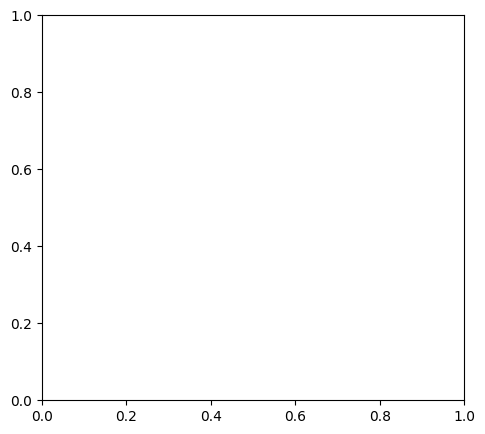

In [13]:
plt.figure(figsize=(12, 5))

# Histogramme prix par mettre carré
plt.subplot(1, 2, 1)  # des graphiques une ligne et deux colonnes, on applique sur le graphique à gauche.
plt.hist(df['Prix_m2'], bins=10, edgecolor='black', alpha=0.7)
plt.axvline(np.median(df['Prix_m2']), color='red', linestyle='--', 
            label=f'Médiane: {np.median(df['Prix_m2']):.2f}')
plt.title('Prix du mettre carré des logements CROUS disponibles pour S2')
plt.xlabel('Rang des prix du m2')
plt.ylabel('Logements disponibles')
plt.legend()

plt.show()

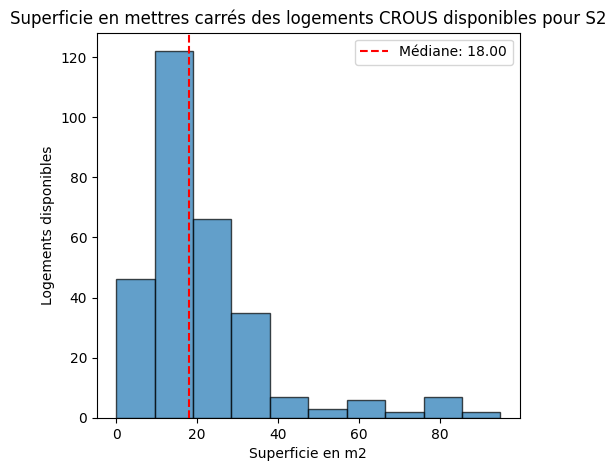

In [14]:
plt.figure(figsize=(12, 5))
# Histogramme par superficie des logements
plt.subplot(1, 2, 1)  # des graphiques une ligne et deux colonnes, on applique sur le graphique à gauche.
plt.hist(df['Superficie_m2'], bins=10, edgecolor='black', alpha=0.7)
plt.axvline(np.median(df['Superficie_m2']), color='red', linestyle='--', 
            label=f'Médiane: {np.median(df['Superficie_m2']):.2f}')
plt.title('Superficie en mettres carrés des logements CROUS disponibles pour S2')
plt.xlabel('Superficie en m2')
plt.ylabel('Logements disponibles')
plt.legend()

plt.show()

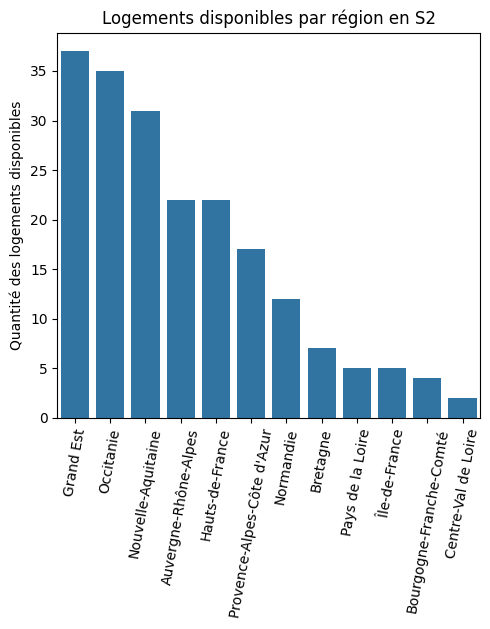

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.countplot(data=df, x='nom_region', order=df['nom_region'].value_counts().index)
plt.title('Logements disponibles par région en S2')
plt.xlabel('')
plt.ylabel('Quantité des logements disponibles')
plt.xticks(rotation=80)

plt.show()

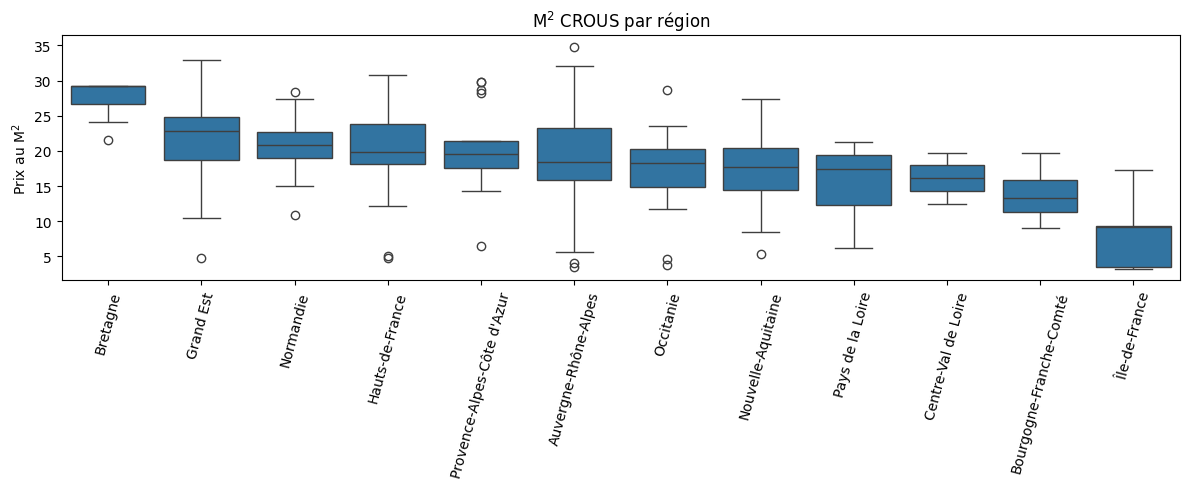

In [16]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=df, x='nom_region', y='Prix_m2', 
            order = df.groupby('nom_region')['Prix_m2'].median().sort_values(ascending=False).index)
plt.xticks(rotation=75)
plt.title('M$^2$ CROUS par région')
plt.xlabel('')
plt.ylabel('Prix au M$^2$')

plt.tight_layout()
plt.show()

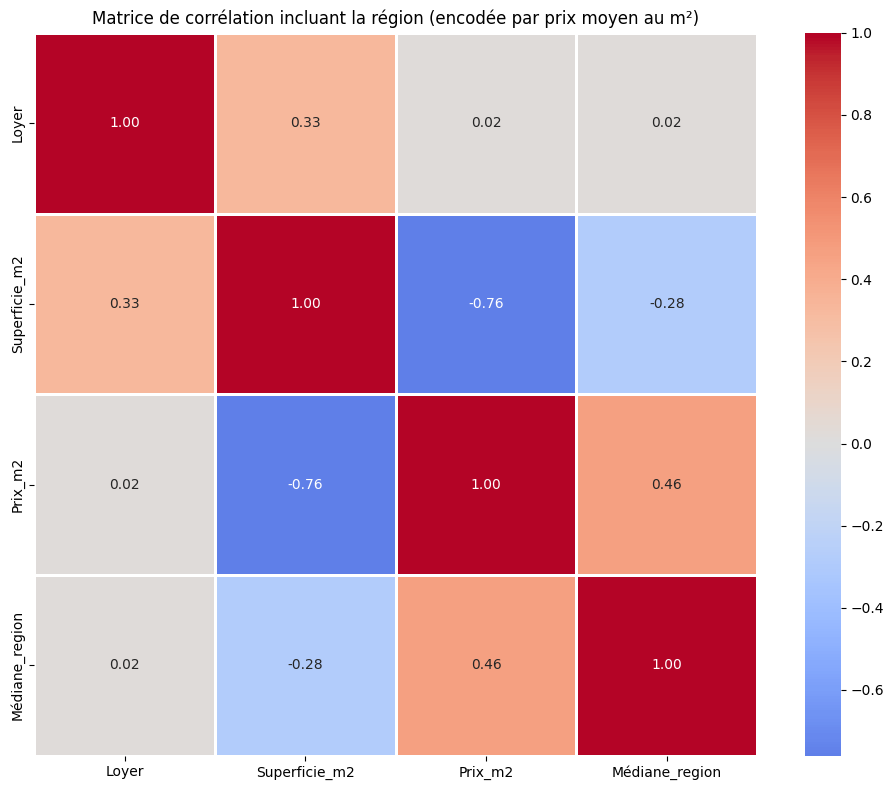

In [17]:
df['Médiane_region'] = df.groupby('nom_region')['Prix_m2'].transform('median')
# Variables pour ta matrice
variables = ['Loyer', 'Superficie_m2', 'Prix_m2', 'Médiane_region']

# Calcul de la corrélation
corr_matrix = df[variables].corr()

# Visualisation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Matrice de corrélation incluant la région (encodée par prix moyen au m²)')
plt.tight_layout()

In [18]:
# Créer une adresse complète (meilleure précision)
df["adresse_complete"] = (
    df["Adresse"].astype(str) + ", " +
    df["code"].astype(str) + " " +
    df["ville"].astype(str) + ", France"
)

In [19]:
import os
import time
import requests
import pandas as pd
from tqdm import tqdm

# df = ton dataframe
# Colonnes attendues : Adresse, ville, code (code postal)

df = df.copy()
df["adresse_complete"] = (
    df["Adresse"].astype(str).str.strip() + ", " +
    df["code"].astype(str).str.strip() + " " +
    df["ville"].astype(str).str.strip()
)

CACHE_PATH = "geocache_ban.csv"

# Charger cache si existe
if os.path.exists(CACHE_PATH):
    cache = pd.read_csv(CACHE_PATH)
else:
    cache = pd.DataFrame(columns=["adresse_complete", "lat", "lon", "score"])

cache = cache.drop_duplicates("adresse_complete").set_index("adresse_complete")

def geocode_ban(address: str, sleep=0.05, retries=5):
    """Géocode via BAN (api-adresse.data.gouv.fr) avec retries."""
    if not address or address.lower() == "nan":
        return None, None, None

    url = "https://api-adresse.data.gouv.fr/search/"
    params = {"q": address, "limit": 1}

    for k in range(retries):
        try:
            r = requests.get(url, params=params, timeout=10)
            r.raise_for_status()
            data = r.json()
            feats = data.get("features", [])
            if not feats:
                return None, None, None

            coords = feats[0]["geometry"]["coordinates"]  # [lon, lat]
            score = feats[0]["properties"].get("score", None)
            lon, lat = coords[0], coords[1]
            time.sleep(sleep)
            return lat, lon, score

        except requests.exceptions.RequestException:
            # backoff exponentiel
            time.sleep(0.5 * (2 ** k))

    return None, None, None

# Appliquer avec cache
lats, lons, scores = [], [], []
new_cache_rows = []

for addr in tqdm(df["adresse_complete"], total=len(df)):
    if addr in cache.index:
        lat, lon, sc = cache.loc[addr, ["lat", "lon", "score"]].tolist()
    else:
        lat, lon, sc = geocode_ban(addr)
        new_cache_rows.append({"adresse_complete": addr, "lat": lat, "lon": lon, "score": sc})
    lats.append(lat); lons.append(lon); scores.append(sc)

df["lat"] = lats
df["lon"] = lons
df["ban_score"] = scores

# Sauver cache mis à jour
if new_cache_rows:
    new_cache_df = pd.DataFrame(new_cache_rows).drop_duplicates("adresse_complete")
    cache_out = pd.concat([cache.reset_index(), new_cache_df], ignore_index=True)
    cache_out = cache_out.drop_duplicates("adresse_complete")
    cache_out.to_csv(CACHE_PATH, index=False)

df_map = df.dropna(subset=["lat", "lon"]).copy()
print("Adresses géocodées :", len(df_map), "/", len(df))


100%|████████████████████████████████████████████████████████████████████████████████| 296/296 [02:16<00:00,  2.17it/s]

Adresses géocodées : 289 / 296


In [22]:
import folium
from folium.plugins import MarkerCluster

m = folium.Map(location=[46.6, 2.5], zoom_start=6)
cluster = MarkerCluster().add_to(m)

for _, row in df_map.iterrows():
    popup = f"""
    <b>{row.get('Adresse','')}</b><br>
    {row.get('code','')} {row.get('ville','')}<br>
    Surface: {row.get('Superficie_m2','')} m²<br>
    Prix/m²: {row.get('Prix_m2','')}<br>
    Score BAN: {row.get('ban_score','')}
    """
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=folium.Popup(popup, max_width=300),
    ).add_to(cluster)

m
m.save("carte_logements.html")
